In [ ]:
import os
import tensorflow as tf

# 1. Force TensorFlow to only see the GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# 2. Enable Memory Growth (Prevents "Out of Memory" errors on RTX 3050)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is active and memory growth is enabled.")
    except RuntimeError as e:
        print(f"GPU Error: {e}")
else:
    print("WARNING: GPU not found. Training will be VERY slow on CPU.")

In [ ]:
from keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [4]:
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("NumPy version:", np.__version__)
import matplotlib
print("Matplotlib version:", matplotlib.__version__)

TensorFlow version: 2.10.0
Keras version: 2.10.0
NumPy version: 1.23.5
Matplotlib version: 3.10.8


In [5]:
image_size = 224
batch_size = 16
channels = 3
epochs = 25

In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage\\train",shuffle=True,
    image_size=(image_size, image_size),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage\\val",
    image_size=(image_size, image_size),
    batch_size=batch_size
)


Found 43389 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.


In [7]:
class_names = train_ds.class_names
print(len(train_ds))

2712


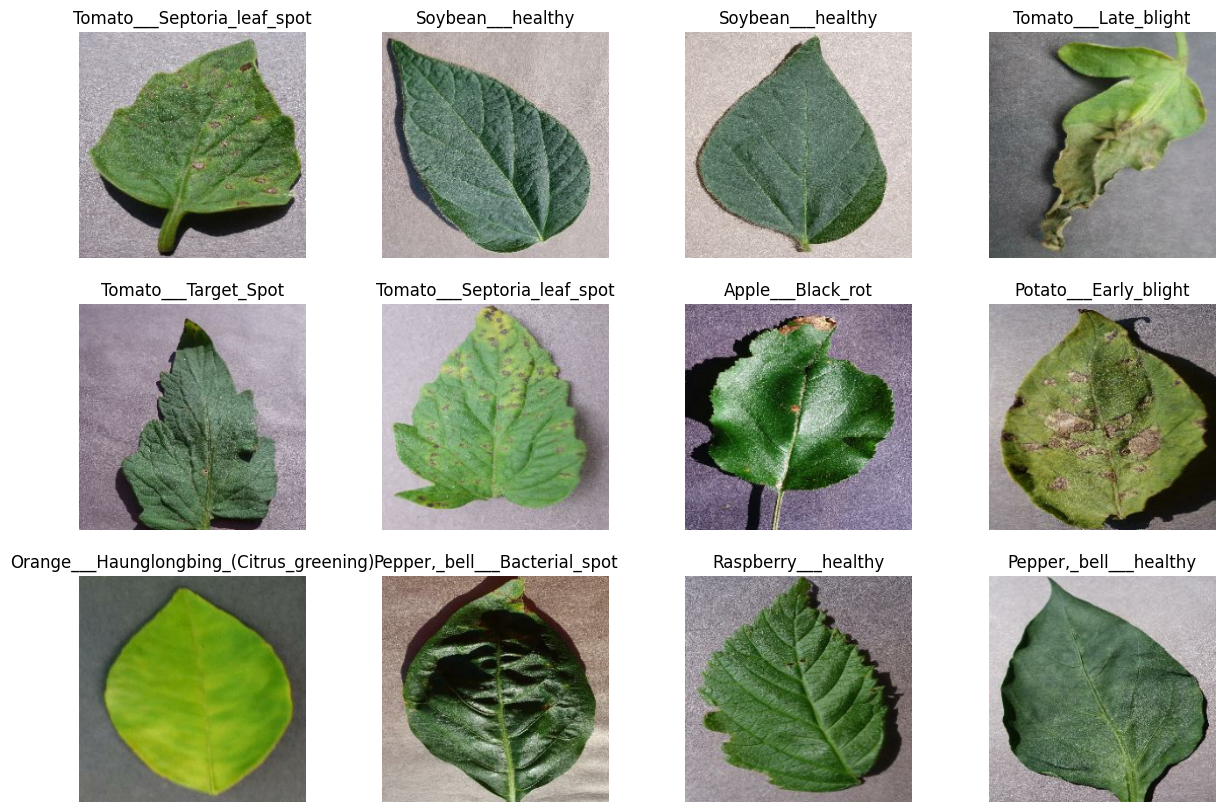

In [8]:
plt.figure(figsize=(15,10))
for image_batch, label_batch in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [9]:
def get_dataset_partitions_tf(val_ds, test_split=0.5, shuffle=True, shuffle_size=10000):
    
    if shuffle:
        val_ds = val_ds.shuffle(shuffle_size, seed=12)

    val_size=int(len(val_ds)*test_split)

    test_ds=val_ds.take(val_size)
    val_ds=val_ds.skip(val_size)
    
    return val_ds, test_ds

In [10]:
val_ds,test_ds=get_dataset_partitions_tf(val_ds)

In [11]:
len(train_ds),len(val_ds),len(test_ds)

(2712, 340, 339)

In [12]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [13]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(image_size, image_size),
    layers.Rescaling(1.0/255)
])

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [15]:
input_shape = (batch_size, image_size, image_size,channels)

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape = (batch_size,image_size, image_size, channels)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(38, activation='softmax')
])

model.build(input_shape=input_shape)

In [16]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (16, 224, 224, 3)         0         
                                                                 
 sequential_1 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                  

In [18]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [29]:
# Wrap your training in the GPU device scope
with tf.device('/GPU:0'):
    # 1. Define the checkpoint
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        'plant_disease_model.h5',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max'
    )

    # 2. Run the training
    history = model.fit(
        train_ds,
        epochs=epochs,
        batch_size=batch_size,
        verbose=2,
        validation_data=val_ds,
        callbacks=[checkpoint]
    )

Epoch 1/25
2712/2712 - 516s - loss: 2.1800 - accuracy: 0.3858 - val_loss: 1.4215 - val_accuracy: 0.5720 - 516s/epoch - 190ms/step
Epoch 2/25
2712/2712 - 443s - loss: 1.0428 - accuracy: 0.6736 - val_loss: 0.7562 - val_accuracy: 0.7572 - 443s/epoch - 164ms/step
Epoch 3/25
2712/2712 - 427s - loss: 0.6942 - accuracy: 0.7794 - val_loss: 0.7074 - val_accuracy: 0.7798 - 427s/epoch - 157ms/step
Epoch 4/25
2712/2712 - 450s - loss: 0.5471 - accuracy: 0.8230 - val_loss: 0.4801 - val_accuracy: 0.8468 - 450s/epoch - 166ms/step
Epoch 5/25
2712/2712 - 446s - loss: 0.4586 - accuracy: 0.8492 - val_loss: 0.3964 - val_accuracy: 0.8709 - 446s/epoch - 165ms/step
Epoch 6/25
2712/2712 - 423s - loss: 0.4073 - accuracy: 0.8673 - val_loss: 0.3932 - val_accuracy: 0.8696 - 423s/epoch - 156ms/step
Epoch 7/25
2712/2712 - 439s - loss: 0.3641 - accuracy: 0.8790 - val_loss: 0.3590 - val_accuracy: 0.8839 - 439s/epoch - 162ms/step
Epoch 8/25
2712/2712 - 432s - loss: 0.3395 - accuracy: 0.8879 - val_loss: 0.5877 - val_acc

In [19]:
from keras.models import load_model

# Load the model you saved 
model = load_model('plant_disease_model.h5')

In [31]:
history.params

{'verbose': 2, 'epochs': 25, 'steps': 2712}

In [32]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [20]:
scores=model.evaluate(test_ds)

339/339 [==============================] - 47s 29ms/step - loss: 0.2029 - accuracy: 0.9368


In [34]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

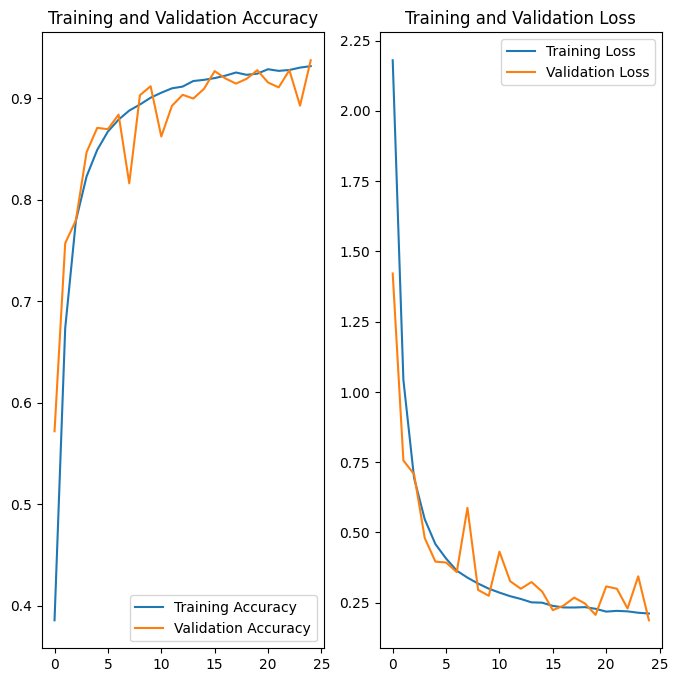

In [35]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(epochs), acc, label='Training Accuracy')
plt.plot(range(epochs), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(epochs), loss, label='Training Loss')
plt.plot(range(epochs), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [21]:
scores

[0.2029099315404892, 0.9367625117301941]

In [22]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) # Create a batch

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 31ms/step


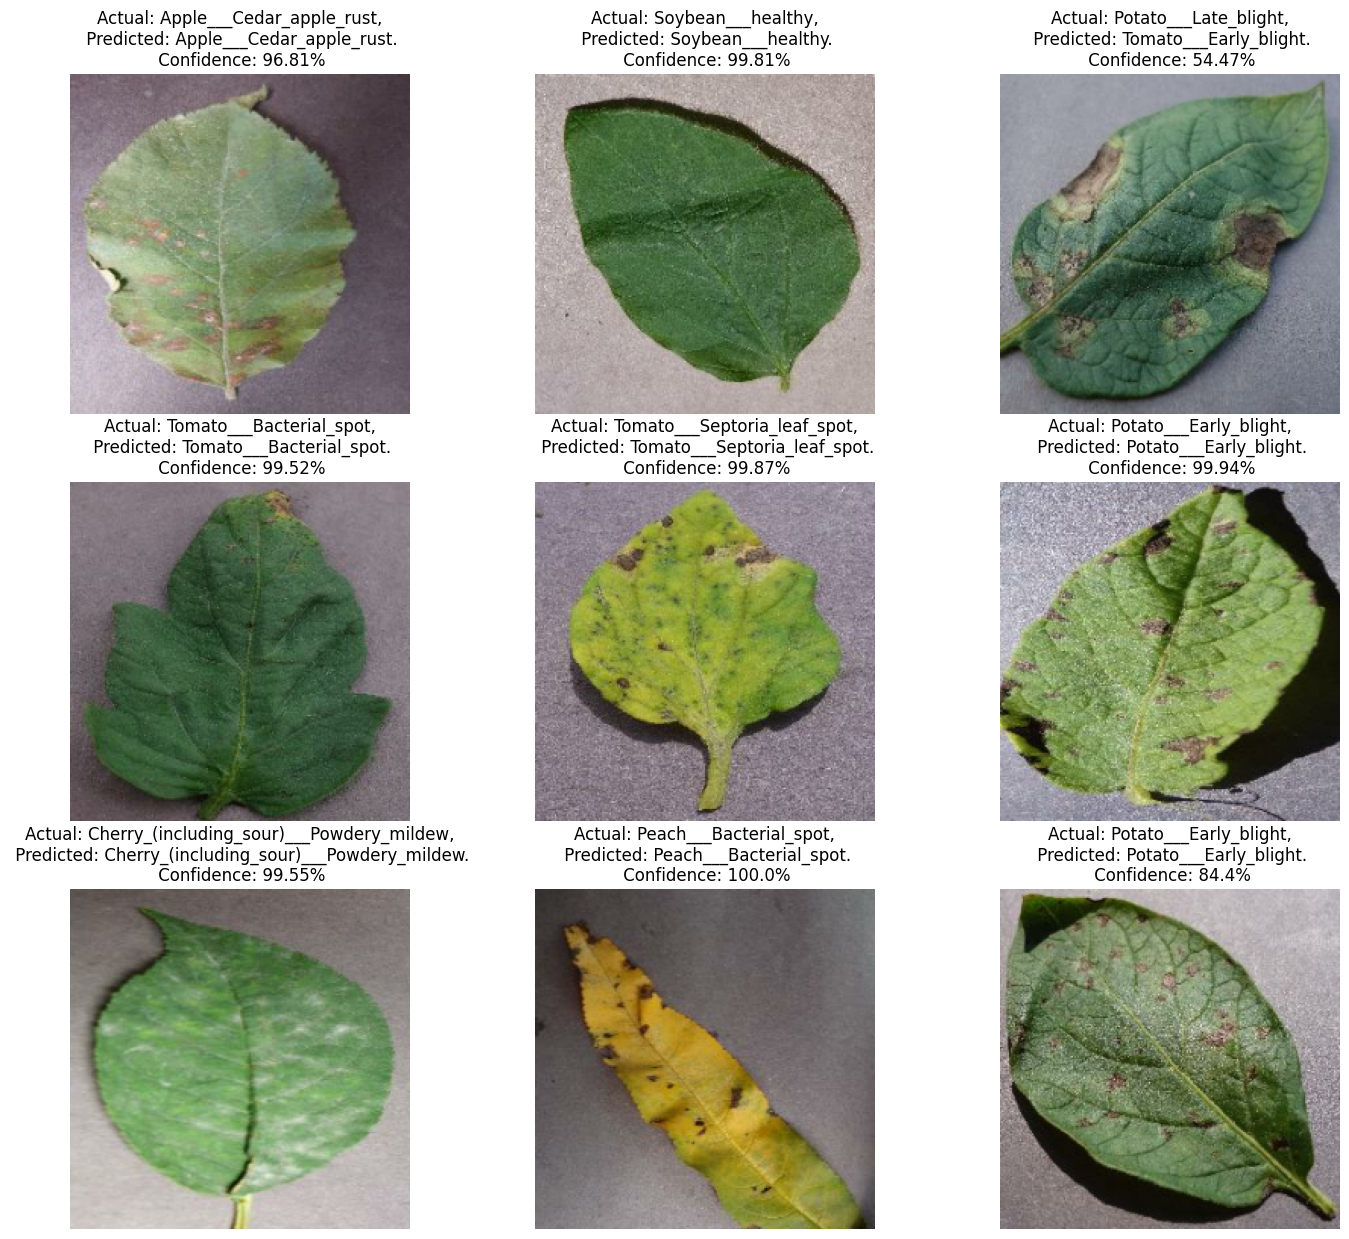

In [23]:
plt.figure(figsize=(17, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")